## Импорты и настройка путей

In [1]:
import random
from pathlib import Path
import matplotlib.pyplot as plt

import numpy as np
from PIL import Image


RANDOM_STATE = 42
DATA_DIR = Path("../data")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"

## Баланс классов

In [2]:
train_counts = {}
for cls_dir in sorted(TRAIN_DIR.iterdir()):
    if cls_dir.is_dir():
        # Считаем ТОЛЬКО .jpg файлы
        imgs = [f for f in cls_dir.iterdir() if f.suffix.lower() == '.jpg']
        train_counts[cls_dir.name] = len(imgs)

print("Train распределение:")
for cls, cnt in train_counts.items():
    print(f"  {cls}: {cnt} изображений")
print(f"  Итого: {sum(train_counts.values())}")

# Считаем test (только .jpg)
test_imgs = [f for f in TEST_DIR.iterdir() if f.suffix.lower() == '.jpg']
print(f"\nTest: {len(test_imgs)} изображений")

Train распределение:
  cleaned: 20 изображений
  dirty: 20 изображений
  Итого: 40

Test: 744 изображений


Целевая переменная в трейн-выборке сбалансирована 50% / 50% по 20 изображений каждого класса

## Размеры изображений

\ TRAIN:
  Всего: 40
  Ширина:  min=256, max=454, mean=326
  Высота:  min=256, max=455, mean=283
  Уникальных размеров: 6
\ TEST:
  Всего: 744
  Ширина:  min=256, max=454, mean=337
  Высота:  min=256, max=454, mean=261
  Уникальных размеров: 5


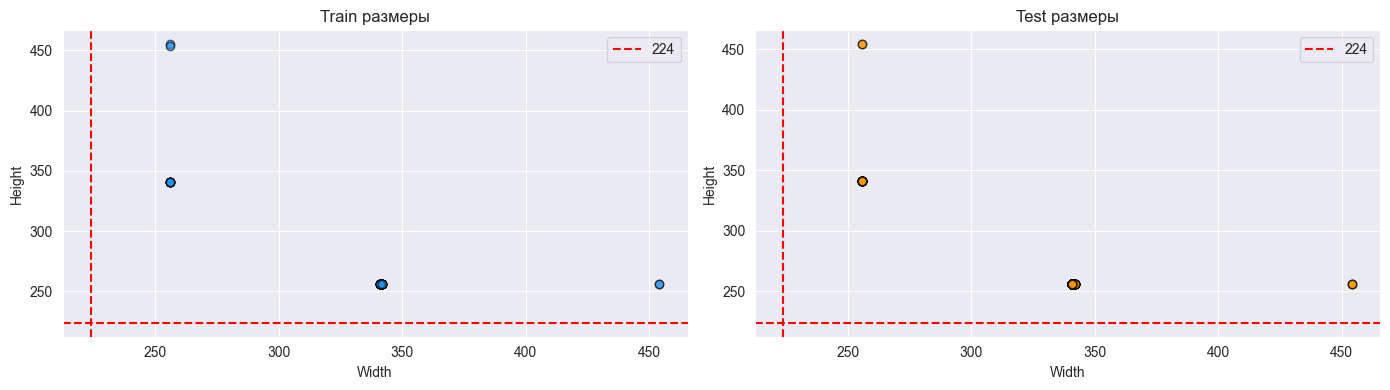

In [3]:
def get_image_sizes(directory):
    sizes = []
    for img_path in directory.rglob('*'):
        if img_path.suffix.lower() in {'.jpg', '.jpeg', '.png'}:
            with Image.open(img_path) as img:
                sizes.append(img.size)
    return sizes

train_sizes = get_image_sizes(TRAIN_DIR)
test_sizes = get_image_sizes(TEST_DIR)

def print_sizes(sizes, name):
    widths = [s[0] for s in sizes]
    heights = [s[1] for s in sizes]
    print(f"\ {name}:")
    print(f"  Всего: {len(sizes)}")
    print(f"  Ширина:  min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}")
    print(f"  Высота:  min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}")
    print(f"  Уникальных размеров: {len(set(sizes))}")

print_sizes(train_sizes, "TRAIN")
print_sizes(test_sizes, "TEST")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter([s[0] for s in train_sizes], [s[1] for s in train_sizes], 
                alpha=0.6, c='#2196F3', edgecolors='black')
axes[0].set_title('Train размеры')
axes[0].set_xlabel('Width')
axes[0].set_ylabel('Height')
axes[0].axhline(y=224, color='r', linestyle='--', label='224')
axes[0].axvline(x=224, color='r', linestyle='--')
axes[0].legend()

axes[1].scatter([s[0] for s in test_sizes], [s[1] for s in test_sizes], 
                alpha=0.6, c='#FF9800', edgecolors='black')
axes[1].set_title('Test размеры')
axes[1].set_xlabel('Width')
axes[1].set_ylabel('Height')
axes[1].axhline(y=224, color='r', linestyle='--', label='224')
axes[1].axvline(x=224, color='r', linestyle='--')
axes[1].legend()

plt.tight_layout()
plt.show()

Train и test согласованы по размерам. 

Все изображения примерно квадратные → можно использовать resize 224x224 без сильных искажений. 

Мало уникальных размеров (6) → вероятно, снимали на одну камеру в стандартных разрешениях.


## Посмотрим на изображения

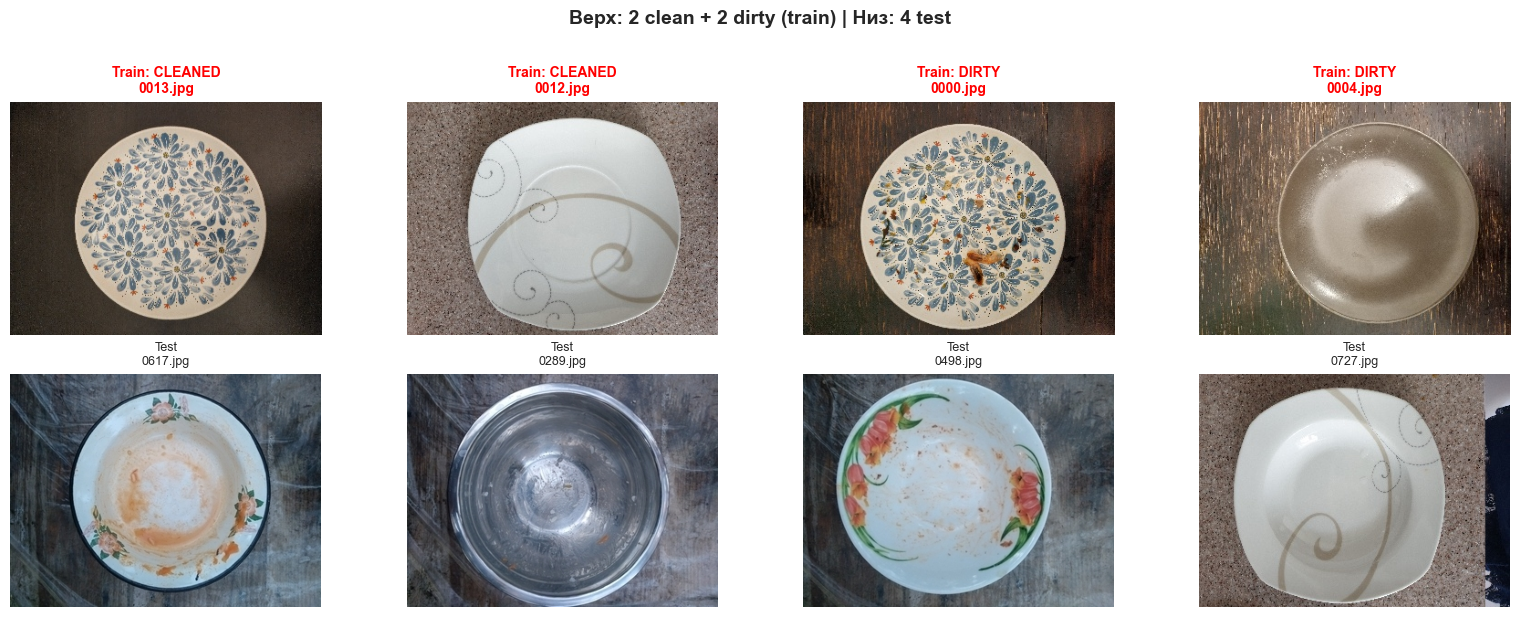

In [4]:
clean_dir = TRAIN_DIR / "cleaned"
dirty_dir = TRAIN_DIR / "dirty"

# Собираем списки путей ко всем .jpg файлам
clean_files = list(clean_dir.glob('*.jpg'))
dirty_files = list(dirty_dir.glob('*.jpg'))
test_files = list(TEST_DIR.glob('*.jpg'))

random.seed(RANDOM_STATE) 

# Выбираем по 2 случайных файла из каждого класса и 4 из test
clean_sample = random.sample(clean_files, 2)
dirty_sample = random.sample(dirty_files, 2)
test_sample = random.sample(test_files, 4)

train_sample = clean_sample + dirty_sample
train_labels = ["cleaned"] * 2 + ["dirty"] * 2

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

# Верхняя строка: 4 из train (2 clean + 2 dirty)
for i, (img_path, label) in enumerate(zip(train_sample, train_labels)):
    img = Image.open(img_path)
    axes[i].imshow(img)
    color = "green" if label == "clean" else "red"
    axes[i].set_title(f"Train: {label.upper()}\n{img_path.name}", 
                      fontsize=10, color=color, fontweight='bold')
    axes[i].axis('off')

# Нижняя строка: 4 из test
for i, img_path in enumerate(test_sample):
    img = Image.open(img_path)
    axes[i + 4].imshow(img)
    axes[i + 4].set_title(f"Test\n{img_path.name}", fontsize=9)
    axes[i + 4].axis('off')

plt.suptitle('Верх: 2 clean + 2 dirty (train) | Низ: 4 test', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Видим, что форма тарелок может быть разной, присутствует орнамент и рисунок по периметру => будем применять пространственные аугментации: повороты, флипы RandomResizedCrop, RandomRotation, RandomHorizontalFlip
 
Освещение разное, есть блики => аугментации яркости/контрастности ColorJitter(brightness, contrast). 

На тестовой выборке фон поход похож на заблюренный (полиэтилен поверх покрытия) => блюр/туман GaussianBlur

Признаки "грязности": пятна, крошки => модель должна быть чувствительна к мелким деталям -> cохраняем высокое разрешение через RandomResizedCrop с scale=(0.8, 1.0)